# ENEM 2025: inscritos, participação e desempenho

**4.811.338 inscrições confirmadas** no [balanço do Inep de 09/11/2025](https://download.inep.gov.br/enem/outros_documentos/enem_balanco_da_aplicacao_09_11_2025.pdf). É o total de inscrições confirmadas, não de pedidos de inscrição ou de isenção. O mesmo total aparece na [publicação oficial de 11/08/2025](https://www.gov.br/mulheres/pt-br/central-de-conteudos/noticias/2025/agosto/mulheres-lideram-inscricoes-no-enem-2025-e-somam-60-dos-participantes), com informações do MEC. Consulta em 22/09/2026: tabela do PDF recuperada pelo índice de busca; abertura direta indisponível.

Nos arquivos divulgados, contamos **4.810.772 registros em PARTICIPANTES** e **4.810.772 em RESULTADOS**. São 566 registros a menos em cada arquivo que o total oficial; **não estabelecemos a causa dessa diferença**. Ter o mesmo volume não torna as bases vinculáveis: seus identificadores são distintos e não há chave individual comum.

A seguir, acompanhamos **RESULTADOS 2025**. Os percentuais de participação continuam usando seus **4.810.772 registros**, sem trocar o denominador pelo total oficial. Primeiro os dias, depois as notas por área e a redação.

A apresentação lê agregados e auditorias já validados. Não reconstrói a trusted nem atualiza CSVs ou relatórios. Cópias externas preservam as saídas para leitura, mas dependem do ambiente e dos arquivos do projeto para execução.


In [1]:
from pathlib import Path
import sys
import json
import hashlib
import pandas as pd
from IPython.display import display, Image

raiz = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "src/participacao_graficos.py").is_file())
if str(raiz) not in sys.path:
    sys.path.insert(0, str(raiz))
from src.participacao_graficos import gerar_graficos_participacao, numero, porcentagem, NOMES

def conferir_hash(caminho, esperado):
    with caminho.open("rb") as arquivo:
        obtido = hashlib.file_digest(arquivo, "sha256").hexdigest()
    if obtido != esperado:
        raise ValueError(f"Arquivo diverge da auditoria: {caminho.name}")

auditoria_participacao = json.loads((raiz / "reports/validacao_participacao_2025.json").read_text(encoding="utf-8"))
auditoria_notas = json.loads((raiz / "reports/validacao_desempenho_2025.json").read_text(encoding="utf-8"))
conferir_hash(raiz / "trusted/resultados_2025_base.parquet", auditoria_participacao["sha256_depois"])
assert auditoria_participacao["sha256_depois"] == auditoria_notas["sha256_fonte_depois"]
for nome, esperado in auditoria_participacao["hashes_csv"].items():
    conferir_hash(raiz / "analitica" / nome, esperado)
conferir_hash(raiz / "analitica/desempenho_2025.csv", auditoria_notas["sha256_indicadores_csv"])
participacao = auditoria_participacao["resultado"]
resumo_dias = participacao["resumo"]
assert (resumo_dias["total_base"], resumo_dias["presentes_dia1"], resumo_dias["presentes_dia2"], resumo_dias["presentes_ambos"]) == (4810772, 3457555, 3260336, 3244348)
tabela = pd.read_csv(raiz / "analitica/desempenho_2025.csv")
figuras_participacao = gerar_graficos_participacao(participacao, raiz / "apresentacao/graficos")
from src.redacao_graficos import gerar_graficos_redacao
auditoria_redacao = json.loads((raiz / "reports/validacao_redacao_2025.json").read_text(encoding="utf-8"))
inscritos = json.loads((raiz / "reports/validacao_inscritos_2025.json").read_text(encoding="utf-8"))
assert auditoria_redacao["sha256_depois"] == auditoria_participacao["sha256_depois"] == inscritos["sha256_resultados"]
assert inscritos["oficial"]["inscricoes_confirmadas"] == 4811338
assert inscritos["participantes"]["registros"] == inscritos["registros_resultados"] == 4810772
for nome, esperado in auditoria_redacao["hashes_csv"].items():
    conferir_hash(raiz / "analitica" / nome, esperado)
redacao = auditoria_redacao["resultado"]
assert (redacao["final"][0]["n"], redacao["final"][0]["zeros"], redacao["final"][0]["mediana"]) == (3457555, 211859, 600)
assert auditoria_redacao["controles"]["recorte_competencias"] == 3245696
figuras_redacao = gerar_graficos_redacao(redacao, raiz / "apresentacao/graficos")


## O 2º dia teve 197.219 presenças completas a menos que o 1º.

No **1º dia (LC + CH)**, foram **3.457.555 presenças completas — 71,87% da base**. No **2º dia (CN + MT)**, foram **3.260.336 — 67,77%**.

**Achado desta base:** não houve presença isolada em uma das duas áreas do mesmo dia; os pares concordam em todos os registros. Isso foi conferido nos dados, não é uma regra universal. “Presença completa” significa presença nas duas áreas do dia.

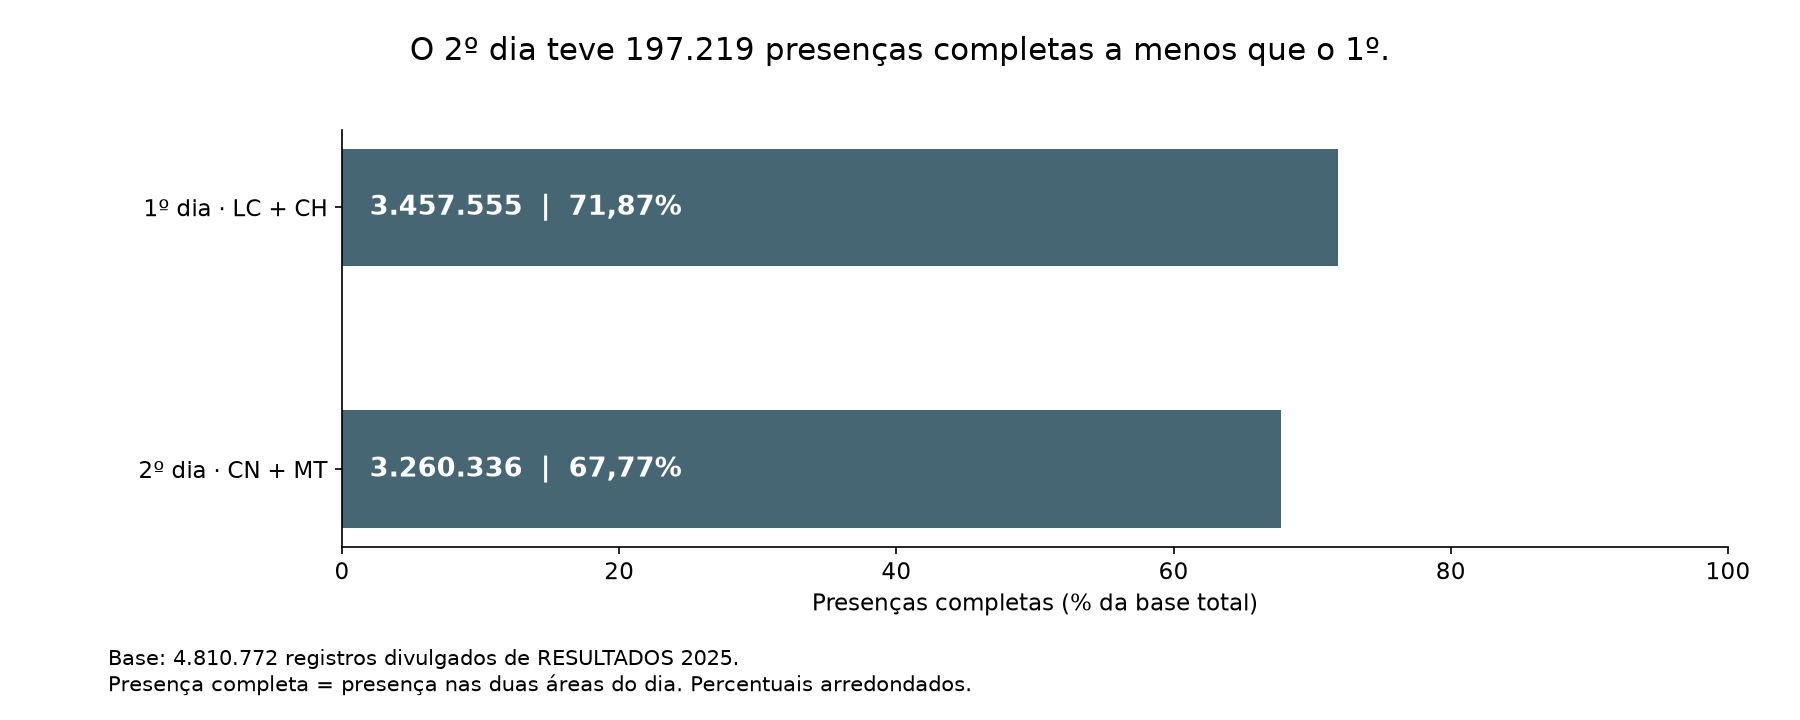

In [2]:
display(Image(filename=str(figuras_participacao[0])))

## Quem continuou presente de um dia para o outro?

**93,83% de quem teve presença completa no 1º dia também esteve presente no 2º dia.**

São **3.244.348** registros com presença completa nos dois dias. O denominador dessa retenção é **3.457.555 presentes completos no 1º dia**, não a base total.

O fluxo acompanha os mesmos registros. O destaque laranja mostra a mudança de presença completa para ausência completa; os demais caminhos ficam em cinza.

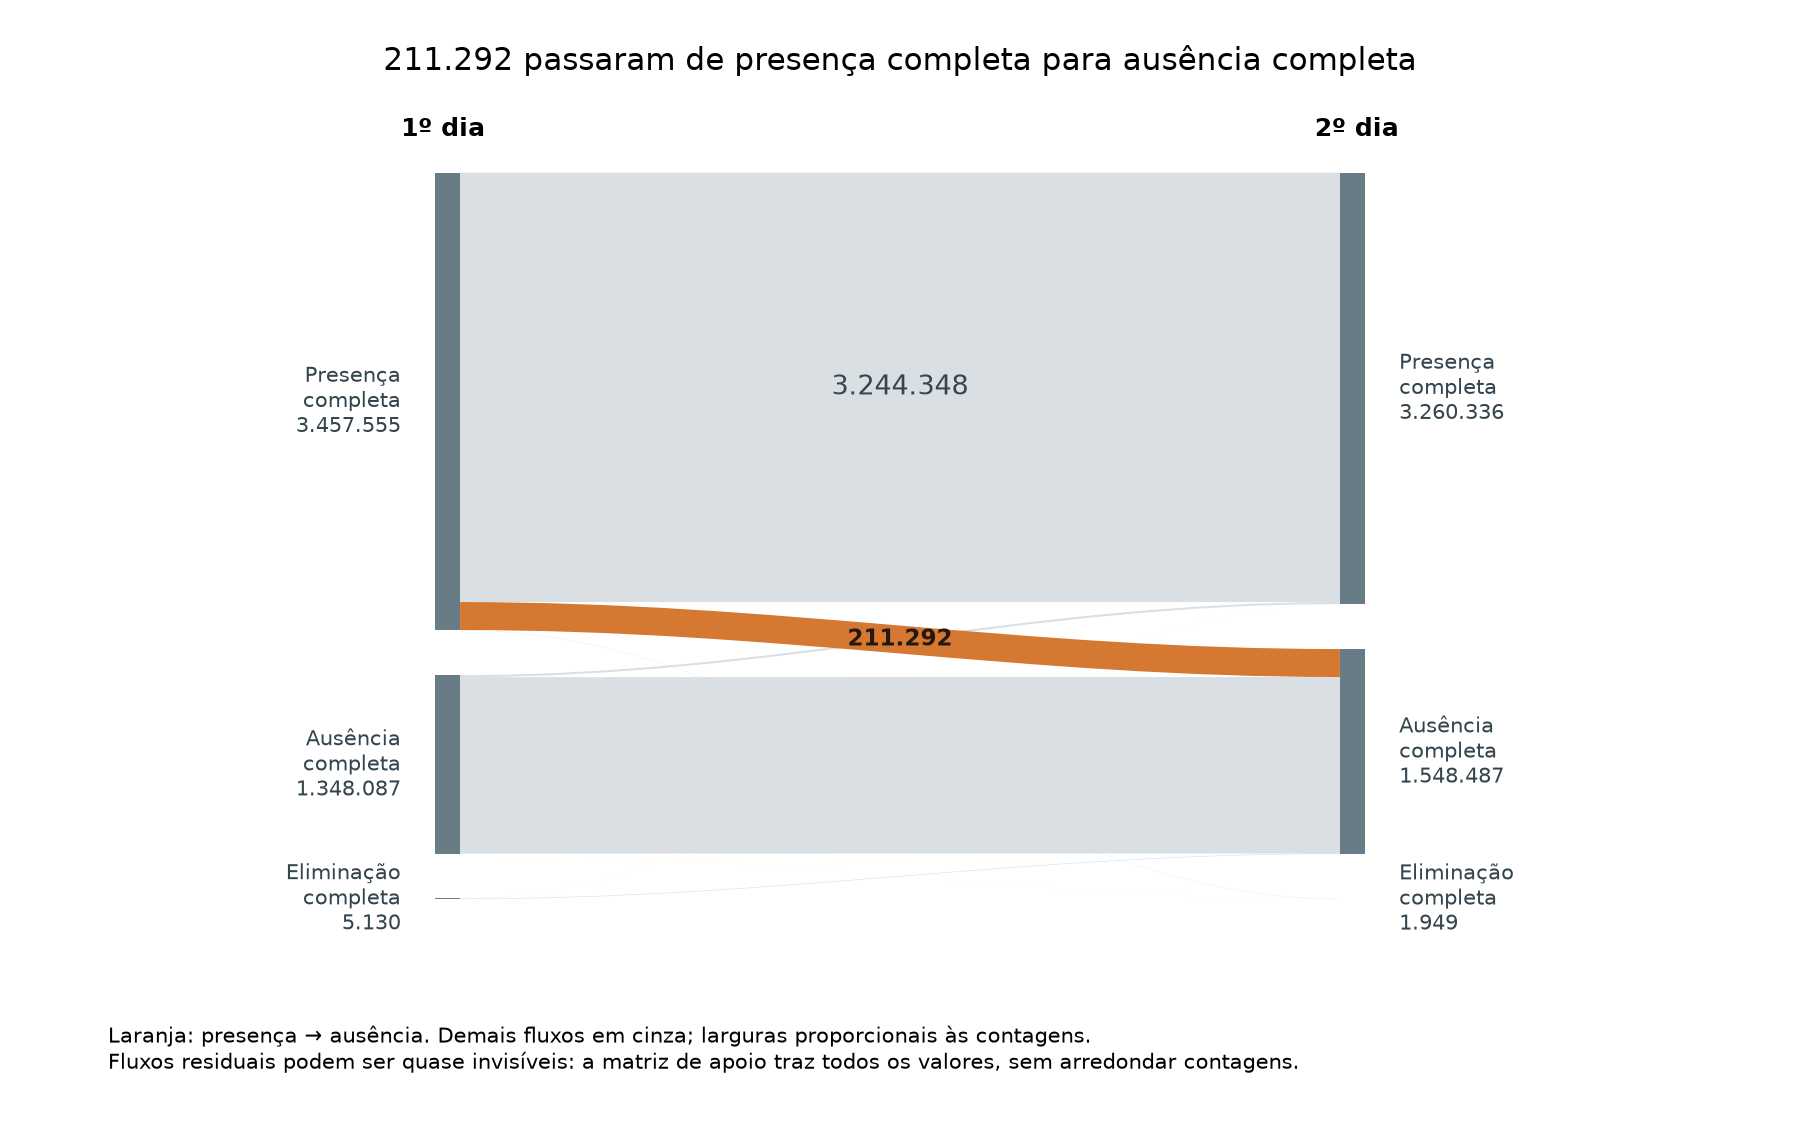

In [3]:
display(Image(filename=str(figuras_participacao[1])))

### Matriz de apoio: nenhum caminho fica de fora

Linhas representam o 1º dia; colunas, o 2º. Cada célula mostra **contagem | % da base total de 4.810.772 registros**. Percentuais positivos menores que 0,01% aparecem como `<0,01%`, não como zero. Situações mistas, dados ausentes e códigos inválidos tiveram zero ocorrência em ambos os dias.

In [4]:
estados = ["presente", "ausente", "eliminado"]
celulas = {(x["dia1"], x["dia2"]): x for x in participacao["transicoes"]}
matriz = pd.DataFrame(
    [[f"{numero(celulas[a, b]['quantidade'])} | {porcentagem(celulas[a, b]['percentual_base'])}" for b in estados] for a in estados],
    index=[NOMES[a] for a in estados], columns=[NOMES[b] for b in estados])
matriz.index.name = "1º dia → 2º dia"
display(matriz)

,Presença completa,Ausência completa,Eliminação completa
1º dia → 2º dia,,,
Presença completa,"3.244.348 | 67,44%","211.292 | 4,39%","1.915 | 0,04%"
Ausência completa,"15.146 | 0,31%","1.332.913 | 27,71%","28 | <0,01%"
Eliminação completa,"842 | 0,02%","4.282 | 0,09%","6 | <0,01%"


## Menos presença no total não significa a mesma quantidade de faltas

**211.292** registros passaram de presença completa para ausência completa. Outros **15.146** fizeram o caminho inverso. E houve mudanças envolvendo eliminação: **1.915** passaram de presença completa para eliminação completa; **842**, de eliminação completa para presença completa.

Por isso, a queda líquida de **197.219** presenças é diferente dos 211.292 que passaram de presente a ausente. A conta fecha assim: **15.146 + 842 − 211.292 − 1.915 = −197.219**. Isso descreve mudanças registradas, sem explicar suas causas.

## Agora, as notas de quem participou

**Agora que entendemos quem chegou a cada dia, analisamos as notas de quem efetivamente participou.**

Cada área inclui somente presentes com nota disponível naquela área, sem exigir presença nas outras áreas. **Zero é mantido.** São 3.260.336 notas elegíveis por área em Natureza e Matemática e 3.457.555 por área em Humanas e Linguagens.

## O centro e a dispersão contam partes diferentes da história

O ponto marca a mediana; a faixa colorida reúne os 50% centrais das notas (Q1–Q3). Em Matemática, essa faixa vai de 416,5 a 606,8, com mediana 500,0 e média 519,98. Esses números descrevem esta população, sem estabelecer dificuldade relativa entre áreas.

A linha fina vai do mínimo ao máximo **observados**, não aos limites teóricos possíveis da prova.

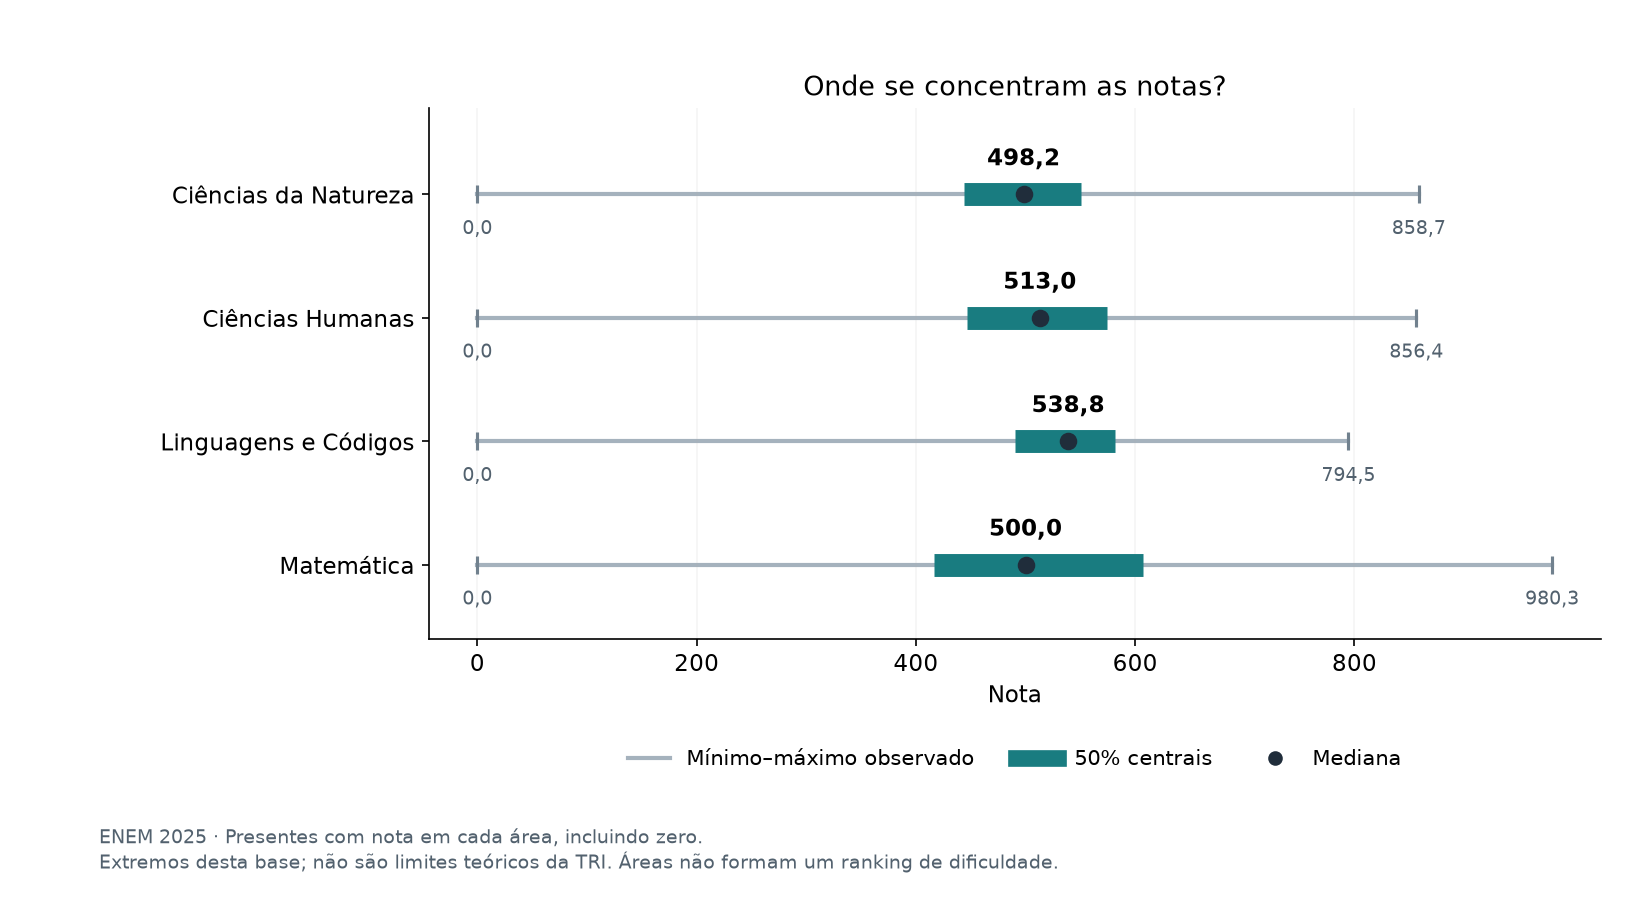

In [5]:
display(Image(filename=str(raiz / "apresentacao/graficos/quartis_por_area_2025.png")))

In [6]:
colunas = {"nome_area":"Área", "elegiveis":"Notas analisadas", "minimo_observado":"Mínimo observado", "q1":"Q1", "mediana":"Mediana", "q3":"Q3", "maximo_observado":"Máximo observado", "media":"Média"}
display(tabela[list(colunas)].rename(columns=colunas).round(2))

,Área,Notas analisadas,Mínimo observado,Q1,Mediana,Q3,Máximo observado,Média
0,Ciências da Natureza,3260336,0.0,443.5,498.2,550.9,858.7,499.97
1,Ciências Humanas,3457555,0.0,446.6,513.0,574.0,856.4,511.19
2,Linguagens e Códigos,3457555,0.0,490.3,538.8,581.6,794.5,532.12
3,Matemática,3260336,0.0,416.5,500.0,606.8,980.3,519.98


## Observado não significa limite teórico

Há notas zero nesta base e elas foram preservadas. Os máximos observados são 858,7 em Natureza, 856,4 em Humanas, 794,5 em Linguagens e 980,3 em Matemática. Isso não estabelece os limites possíveis das provas nem explica a origem de cada zero.

A TRI não tem uma escala universal fixa de 0 a 1000; os limites de uma prova dependem dos itens. Não estimamos esses limites neste trabalho. [Referência: guia do Inep](https://www.gov.br/inep/pt-br/centrais-de-conteudo/acervo-linha-editorial/publicacoes-institucionais/avaliacoes-e-exames-da-educacao-basica/entenda-a-sua-nota-no-enem-guia-do-participante).

## Como foi o desempenho na escrita?

Há **3.457.555 notas finais registradas**, incluindo **211.859 zeros**. A média é **580,80** e a mediana, **600**. Os 50% centrais vão de **480 (Q1) a 720 (Q3)**; mínimo e máximo observados são **0 e 1000**.

Os **1.353.217 registros sem nota** não entram nessa distribuição. Não transformamos nota ausente em zero nem exigimos status “Sem problemas” para analisar a nota final. A redação tem critérios e escala próprios; esses valores não devem ser tratados como equivalentes às notas TRI das áreas.


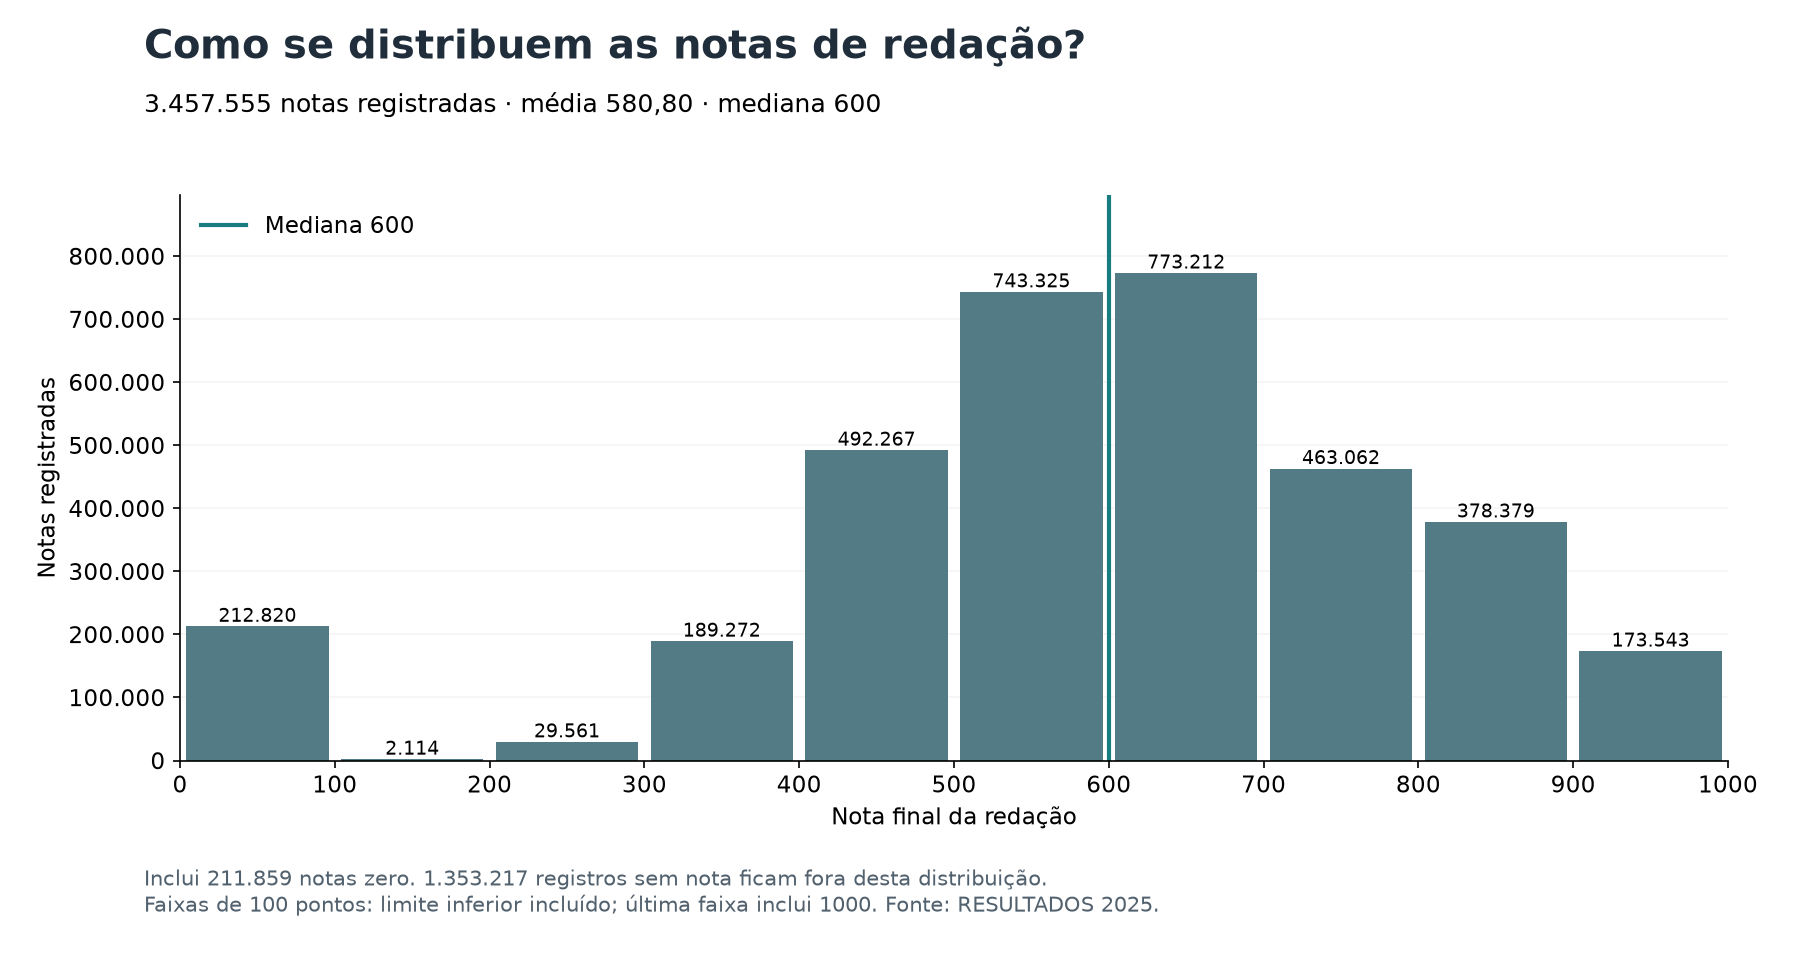

In [7]:
display(Image(filename=str(figuras_redacao[0])))


### Zero, redação em branco e nota ausente são situações diferentes

A tabela cobre **todos os 4.810.772 registros de RESULTADOS**. “Em Branco” é uma situação registrada pelo Inep; “Sem status registrado” é um campo nulo. Nesta base, os 211.859 zeros finais estão nas situações diferentes de “Sem problemas”. Todos foram mantidos na distribuição.

Os 1.353.217 registros sem nota também estão sem status. Dentro de RESULTADOS, 1.348.087 deles estão classificados como ausentes nas duas áreas do 1º dia e 5.130 como eliminados. Isso é uma conferência dos campos desta base, não uma regra que deduz presença na redação a partir de LC/CH.


In [8]:
colunas_status = {"situacao":"Situação registrada", "quantidade":"Registros", "percentual_base":"% da base total", "zeros":"Notas zero", "sem_nota":"Sem nota"}
display(pd.DataFrame(redacao["status"])[list(colunas_status)].rename(columns=colunas_status).round(2))


,Situação registrada,Registros,% da base total,Notas zero,Sem nota
0,Sem problemas,3245696,67.47,0,0
1,Anulada,3070,0.06,3070,0
2,Cópia Texto Motivador,54840,1.14,54840,0
3,Em Branco,114329,2.38,114329,0
4,Fuga ao tema,13576,0.28,13576,0
5,Não atendimento ao tipo textual,5661,0.12,5661,0
6,Texto insuficiente,16975,0.35,16975,0
7,Parte desconectada,3408,0.07,3408,0
8,Sem status registrado,1353217,28.13,0,1353217


### O que as cinco competências mostram neste primeiro recorte?

Para comparar competências, usamos **3.245.696 redações com status “Sem problemas” e as seis notas completas**. Excluímos aqui as **211.859 situações problemáticas** e os **1.353.217 registros sem nota/status**; nenhuma redação “Sem problemas” ficou de fora por falta de nota. O denominador é o mesmo nas cinco competências e **zeros individuais continuam incluídos**.

As cinco medianas são **120 pontos**. As médias vão de **114,15 na proposta de intervenção (C5)** a **136,97 em tema e tipo textual (C2)**. Isso descreve o recorte; não revela por que as notas diferem nem permite diagnosticar causas individuais.


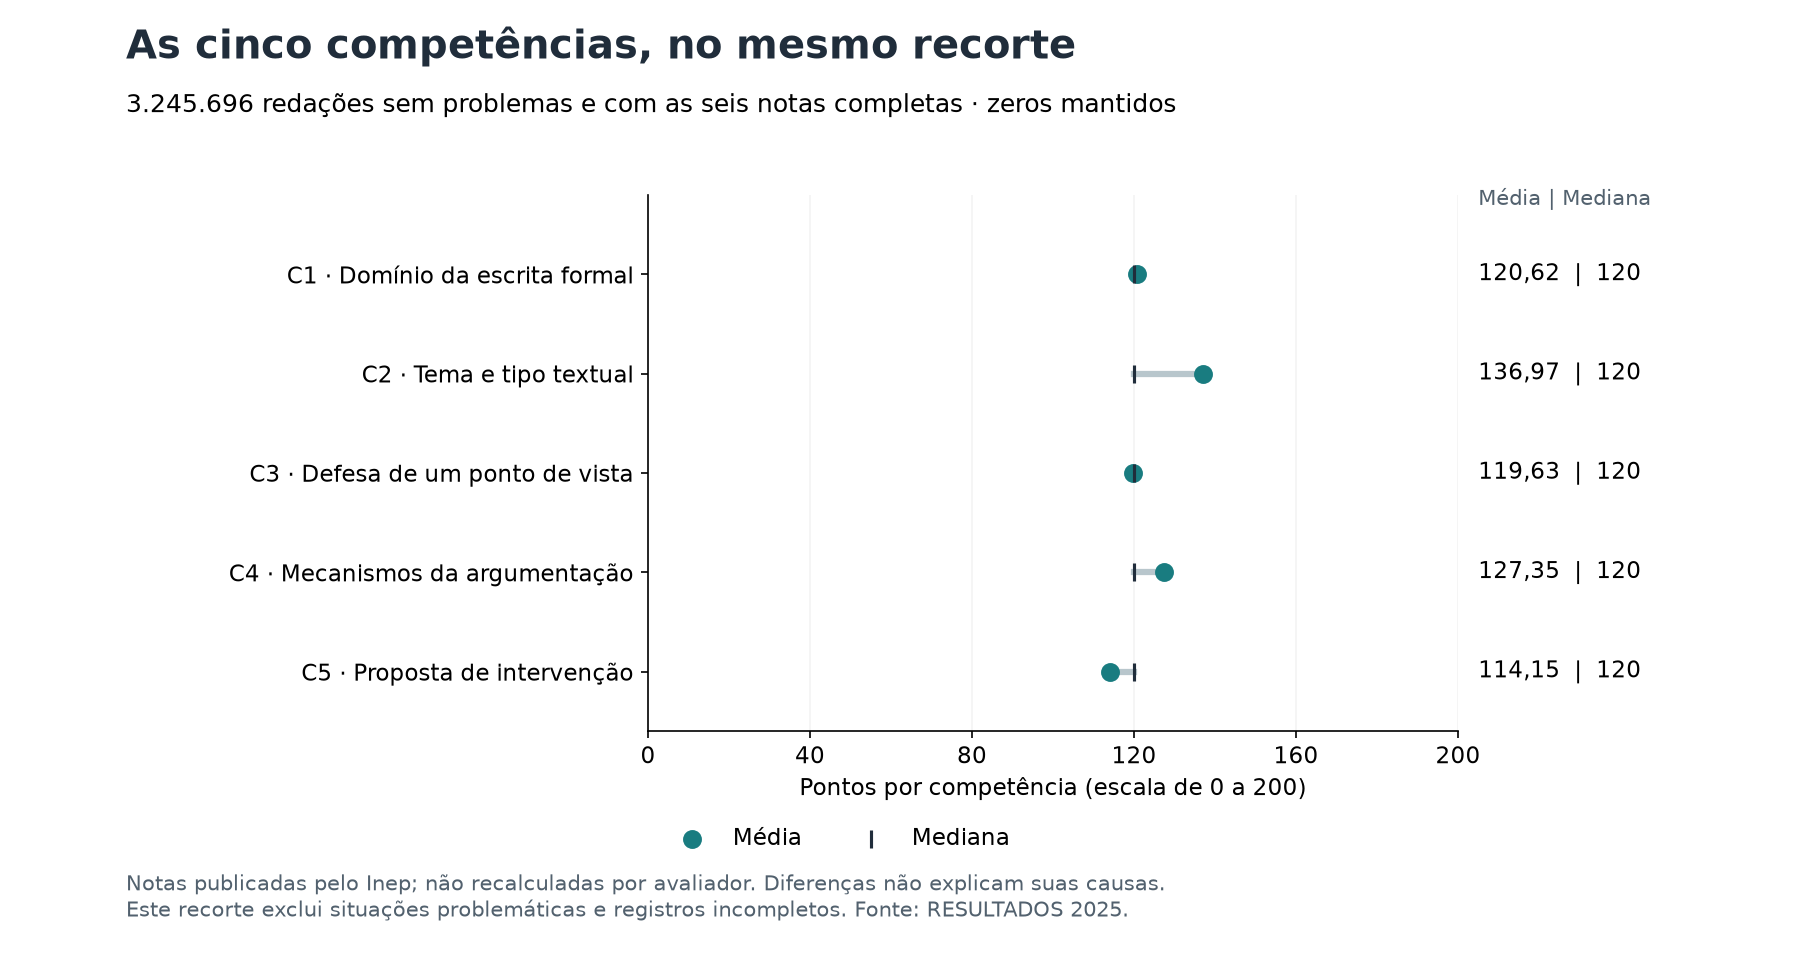

In [9]:
display(Image(filename=str(figuras_redacao[1])))


In [10]:
colunas_comp = {"competencia":"Competência", "n":"Redações analisadas", "media":"Média", "mediana":"Mediana", "q1":"Q1", "q3":"Q3", "zeros":"Notas zero"}
display(pd.DataFrame(redacao["competencias"])[list(colunas_comp)].rename(columns=colunas_comp).round(2))


,Competência,Redações analisadas,Média,Mediana,Q1,Q3,Notas zero
0,Domínio da escrita formal,3245696,120.62,120.0,100.0,140.0,589
1,Tema e tipo textual,3245696,136.97,120.0,120.0,160.0,0
2,Defesa de um ponto de vista,3245696,119.63,120.0,100.0,140.0,1072
3,Mecanismos da argumentação,3245696,127.35,120.0,100.0,160.0,1199
4,Proposta de intervenção,3245696,114.15,120.0,80.0,160.0,305510


A soma das cinco competências coincide com a nota final em **3.457.555 registros comparáveis**, sem divergências. Usamos as notas publicadas pelo Inep; não recalculamos avaliações individuais. Os critérios e recortes estão no contrato analítico de redação em `docs/`.


## O que podemos dizer — e o que ainda não sabemos

Acompanhamos registros divulgados de RESULTADOS 2025. A comparação entre dias não informa motivos de ausência nem demonstra evasão causal. Presença nas áreas não mede horários ou sessões. Inscrições confirmadas e registros divulgados têm universos distintos; a diferença de volume permanece sem causa estabelecida.

Esta é uma **primeira POC de redação para revisão**. Os status explicam o recorte estatístico, sem inferência causal. As competências usam uma população menor que a nota final, com denominadores explícitos.

**Próximas perguntas, ainda não executadas:** presença e notas por região de aplicação, desempenho por rede e perfil econômico independente. Local de prova não é residência. Renda continua sem vínculo individual com notas em 2025.

Os contratos ficam em `docs/`, os CSV em `analitica/` e as auditorias em `reports/`.
